# Comparison of Gene Expression PTRs with Chromatin PTRs

April 15, 2024

Goal: Determine if there is a pattern of difference between peak cycling chromatin and peak cycling gene expression.


Analyze the difference in timing between peak and trough gene expression with peak and trough promoter occupancy.

Eventually, we can explore other measures of the chromatin like nucleosome positioning.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Polar Plot

Goal: Classify genes by their peak and trough gene expression
    
Separately for Mother and Daughter Cells

Output:
1. Time and phase of peak gene expression
2. Time and phase of trough gene expression


In [2]:
from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()

In [3]:
# Refactored to use min max values rather than peak and trough values
# todo: indices of 225 do not have a phase and need to be fixed

ge_analysis.compute_ptr_maxmins_tps()

In [4]:
ge_analysis.ptrs_min_maxs.head(2)

,mother_ptr,daughter_ptr,ptr,min_value,min_f_idx,min_tp,min_phase,max_value,max_f_idx,max_tp,max_phase
orf_name,,,,,,,,,,,
YAL067W-A,1.000799,1.003462,1.001686,4.436323733130215,127,-14.6021,D_G1,4.462289453606121,49,-28.0,C_G1
YAL067C,1.270735,3.001155,1.692257,8.653574920824855e-05,142,-3.4408,D_G1,10.387151140225065,174,13.9203,D_S


In [5]:
dse_genes = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
xin_dg1_genes = ['ASH1','EGT2','AMN1','PRY3','SCW11','CTS1']

genes_mapping = {'red': xin_dg1_genes, 'blue': dse_genes}


Text(0.5, 1.0, 'Gene expression PTR per cell-cycle phase')

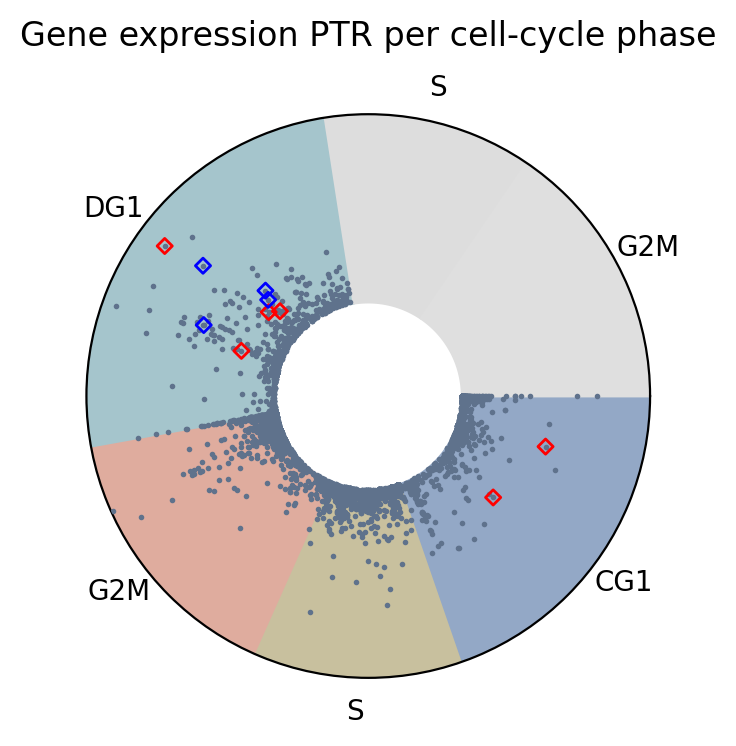

In [6]:
from src.PolarPlotter import PolarPlotter

polar_plotter = PolarPlotter()
ge_ptr_tp_rad_df = polar_plotter.plot_scatter_polar_full(ge_analysis.ptrs_min_maxs, 
    selected_genes_mapping=genes_mapping, ylim=(0.5, 2))
plt.title("Gene expression PTR per cell-cycle phase", pad=10)

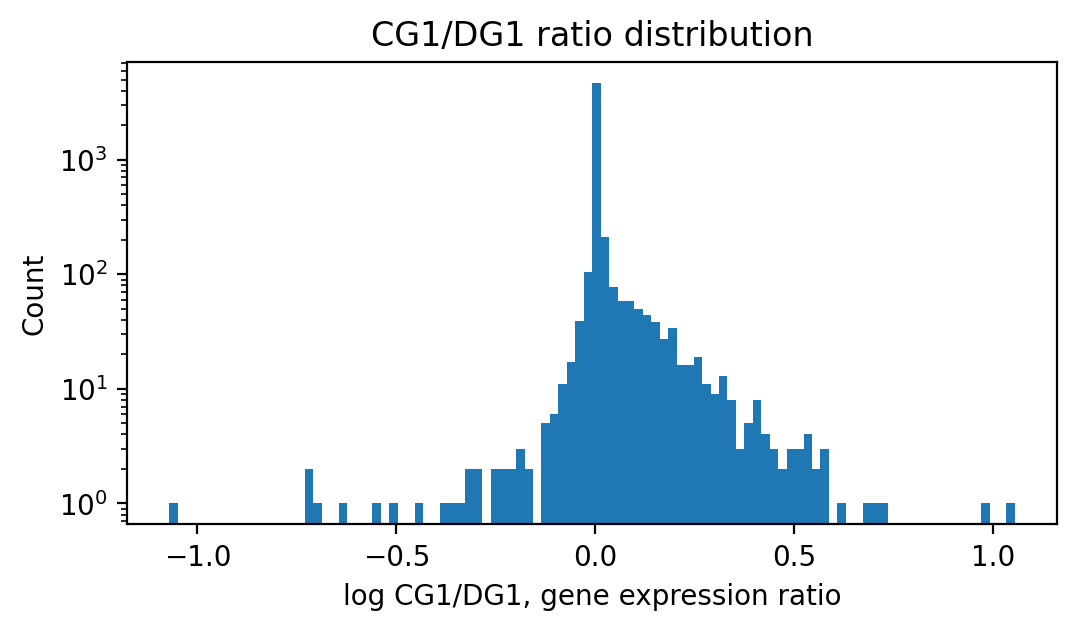

In [7]:
ge_analysis.plot_cg1_dg1_ratio()

# When setting the beta parameter, do we artificially place high PTR genes in DG1?
# How do we know there could be an identifiability problem? Do we overfit for putting the 
# DSE genes in DG1?


In [8]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

In [9]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.020
1001/5574 - 00:00:04.576
2001/5574 - 00:00:09.713
3001/5574 - 00:00:14.625
4001/5574 - 00:00:19.556
5001/5574 - 00:00:24.412


In [10]:
promoter_analysis.correct_f_images_by_strand()

In [11]:
promoter_analysis.compute_small_fragments_promoter_occupancy()

In [12]:
promoter_analysis.compute_ptr_min_maxes()

Text(0.5, 1.0, 'Promoter occupancy PTR per cell-cycle phase')

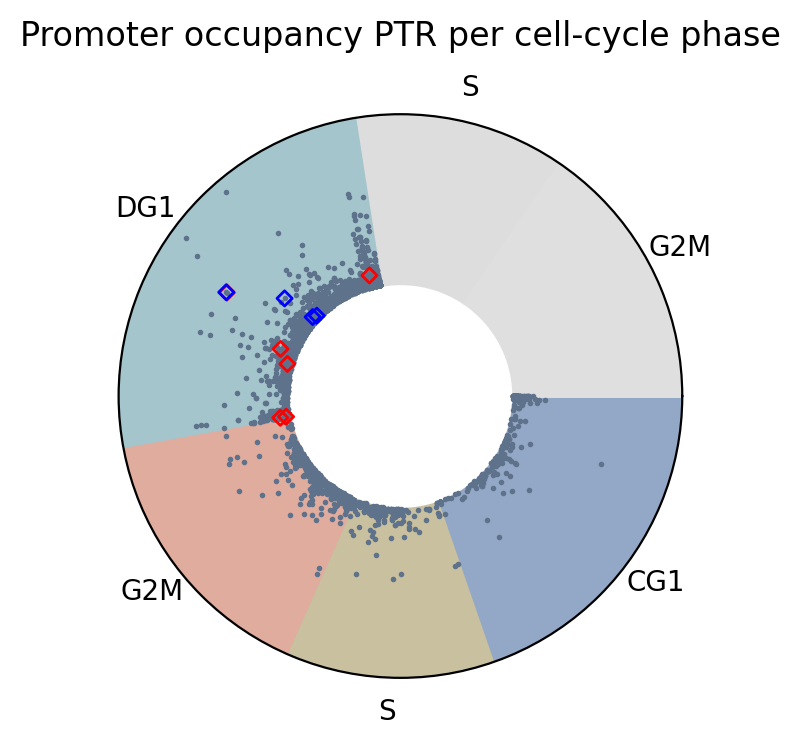

In [13]:
from src.PolarPlotter import PolarPlotter

polar_plotter = PolarPlotter()
prom_ptr_tp_rad_df = polar_plotter.plot_scatter_polar_full(promoter_analysis.promoter_min_maxs, 
    selected_genes_mapping=genes_mapping, ylim=(-5, 10))
plt.title("Promoter occupancy PTR per cell-cycle phase", pad=10)


In [14]:
from src.TimeDeltaAnalysis import TimeDeltaAnalysis

time_delta_analysis = TimeDeltaAnalysis(ge_analysis, promoter_analysis)

In [15]:
# Compute the time deltas for the mother and daughter branches for gene expression and 
# promoter occupancy separately

# Start by computing the max and mins for the gene expression
# Previously this was done across mother and daughter together, let's do them separately.
from src.TimeDeltaAnalysis import TimeDeltaAnalysis, compute_mother_daughter_max_mins


time_delta_analysis = TimeDeltaAnalysis(ge_analysis, promoter_analysis)

In [68]:
time_delta_analysis.compute_max_mins_deltas()

Computing max mins and deltas for mother and daughter
Done. - 00:01:20.951


Text(0.5, 1.0, 'Mother vs daughter delta between\nexpression and promoter occupancy')

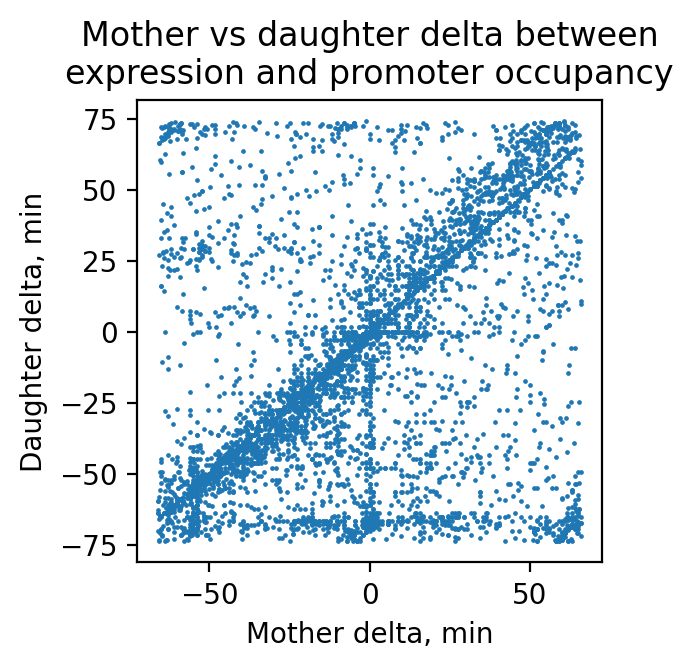

In [99]:
plt.figure(figsize=(3, 3))
plt.scatter(time_delta_analysis.mother_daughter_deltas.delta_min_mother,
         time_delta_analysis.mother_daughter_deltas.delta_min_daughter, s=0.5)
plt.xlabel("Mother delta, min")
plt.ylabel("Daughter delta, min")
plt.title("Mother vs daughter delta between\nexpression and promoter occupancy")

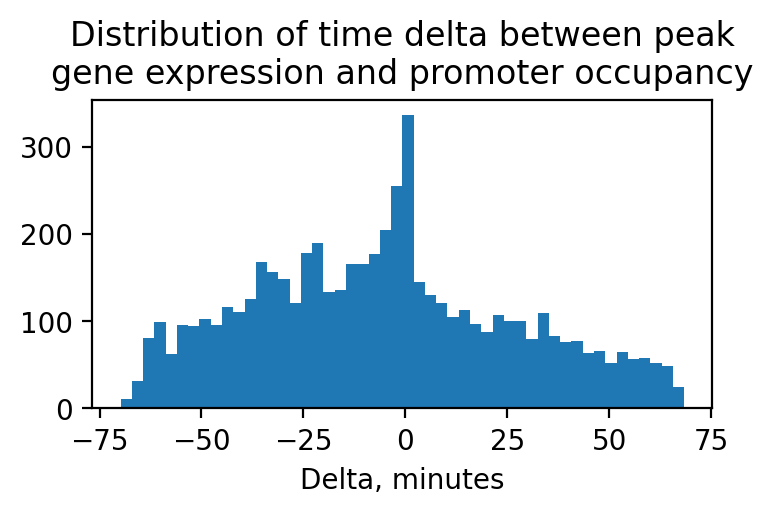

In [79]:
time_delta_analysis.plot_deltas()

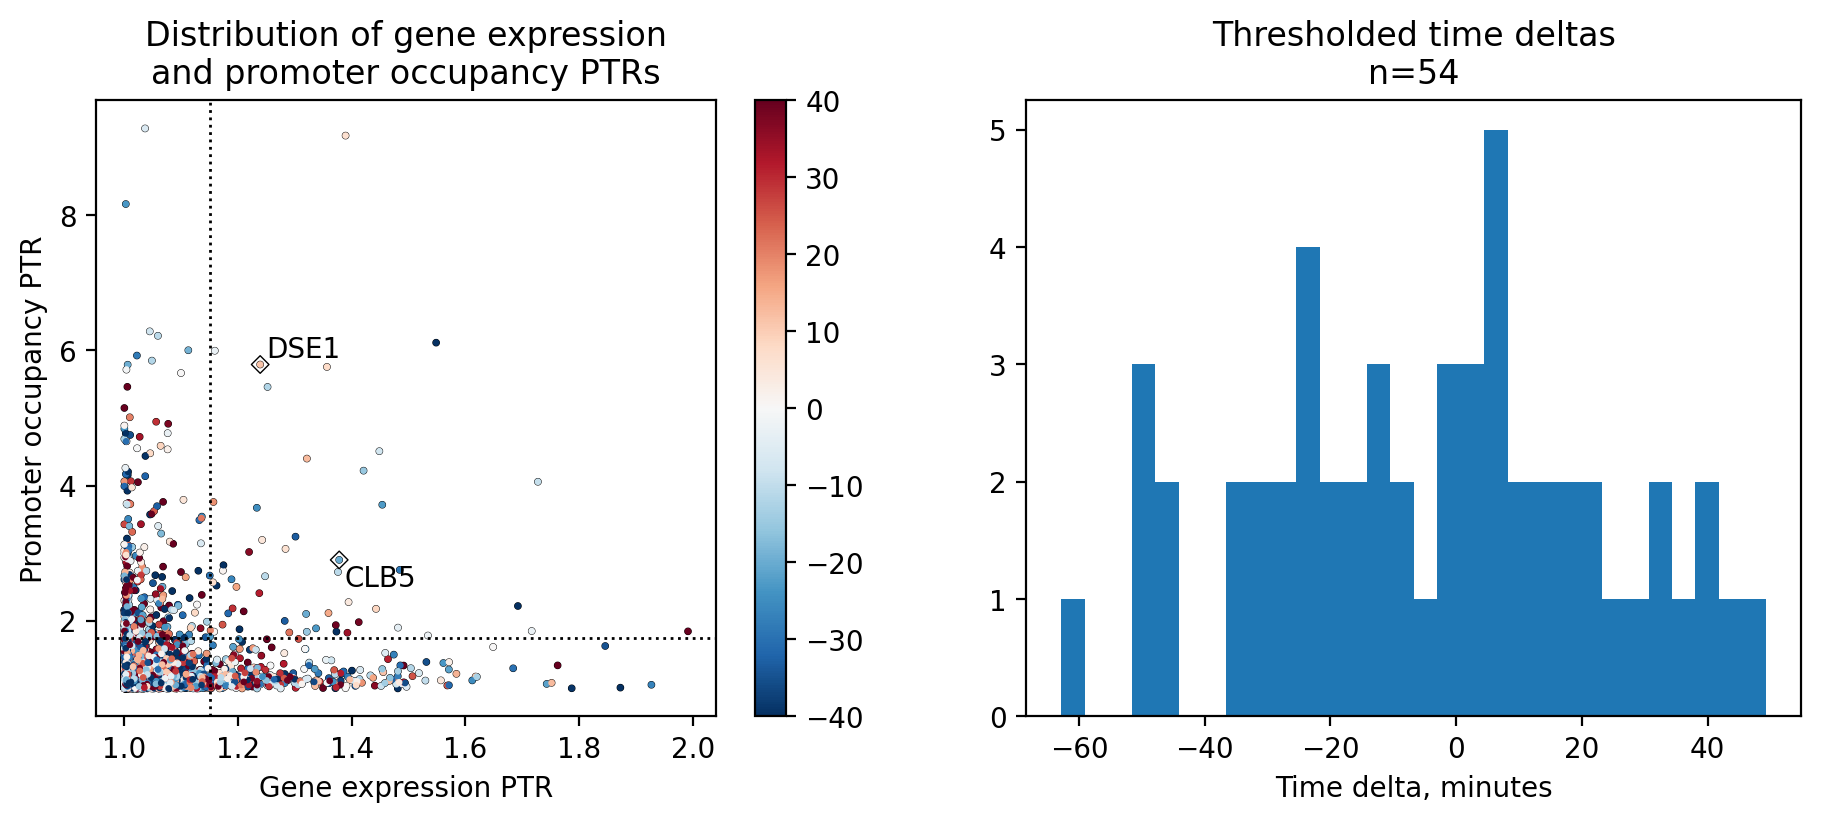

In [106]:
genes_mapping = {'black': ['DSE1', 'CLB5']}

time_delta_analysis.plot_scatter_ptr(genes_mapping=genes_mapping, 
                                    thresholds=(1.15, 1.75))

In [113]:
df = time_delta_analysis.comparison_ptr_df
df[(df.ptr_ge > 1.2) & (df.ptr_prom > 2)].join(ge_analysis.geneset[['gene']]).head()

,ptr_ge,ptr_prom,gene
orf_name,,,
YAL067C,1.692257,2.219635,SEO1
YBR054W,1.548410,6.115157,YRO2
YBR230W-A,1.233036,3.672496,YBR230W-A
YDR224C,1.394386,2.277174,HTB1
YDR524C-B,1.237400,2.409641,YDR524C-B


In [ ]:
time_delta_analysis.compute_promoter_regions()

           tf  loc_corrected
77165   Kin28         -119.5
26495    Ssl1         -144.5
112020   Ssl2         -115.5
161474   Sua7         -104.5
160350   Sua7         -138.5
84437    Tfa1         -104.5
42857    Tfa2         -126.5
80015    Tfb2         -109.5
140686   Tfb3         -125.5
30069    Tfb4         -117.5


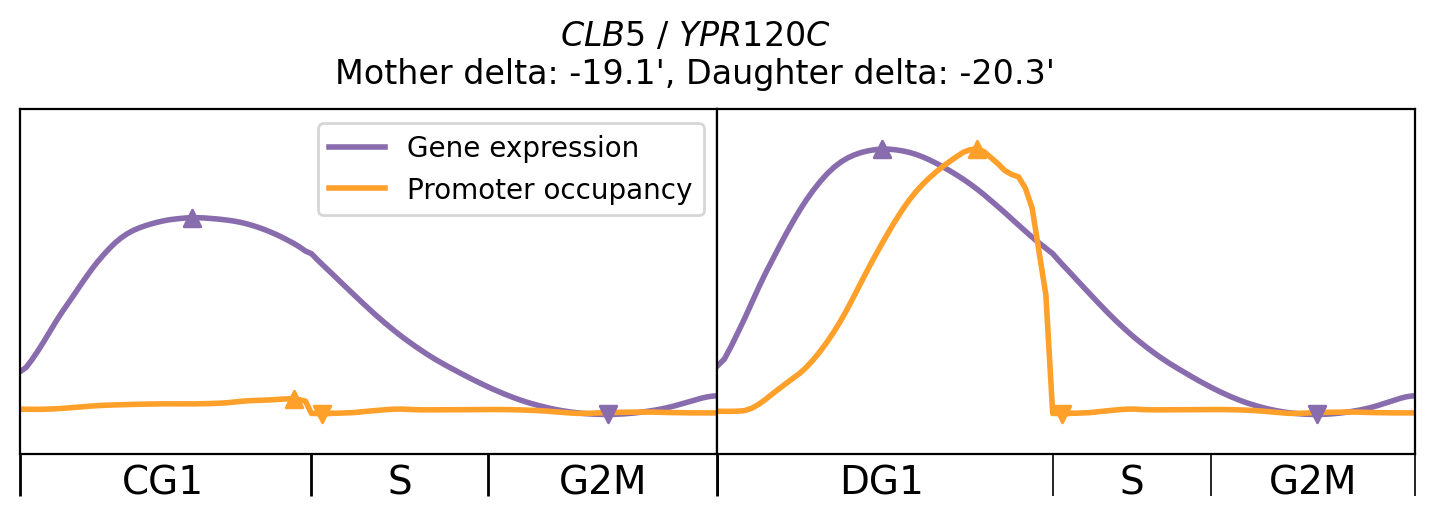

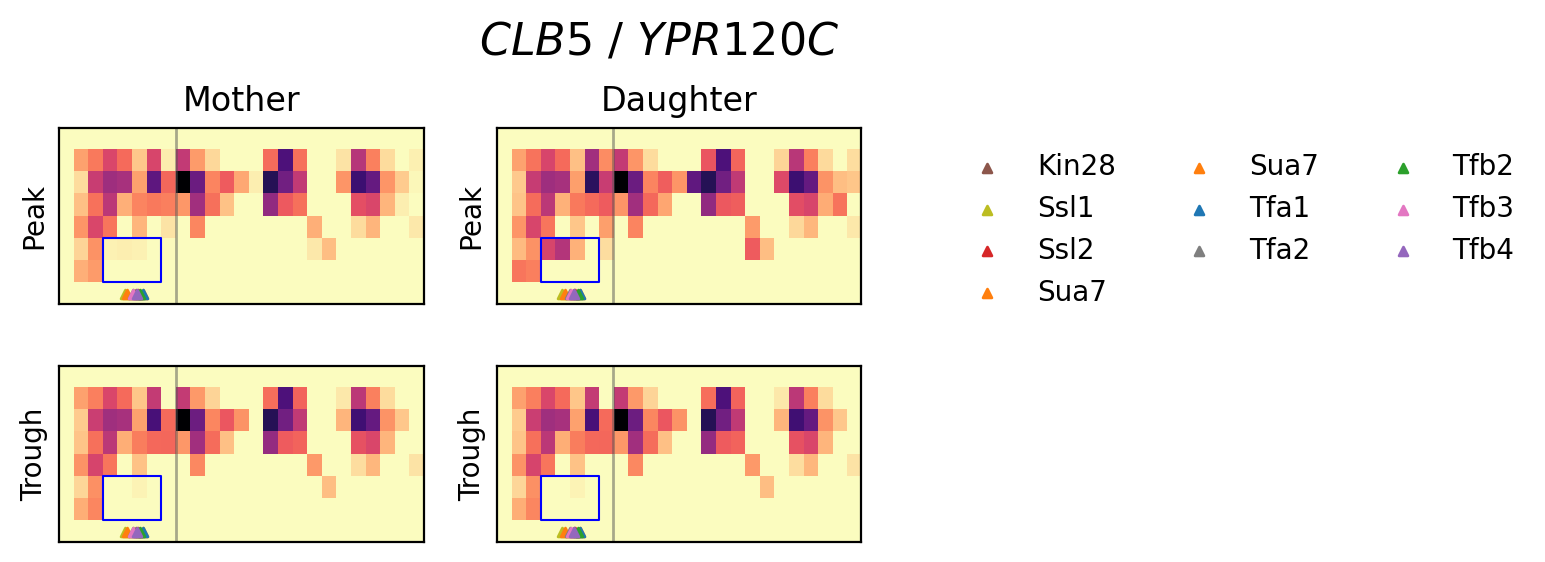

In [430]:
orf_name = 'YPR120C'
time_delta_analysis.plot_gene_trace(orf_name)
promoter_analysis.plot_orf_name_imgs(time_delta_analysis, orf_name)

          tf  loc_corrected
57037   Ace2          -83.0
89268   Fkh1          -83.0
151169  Htz1         -156.0


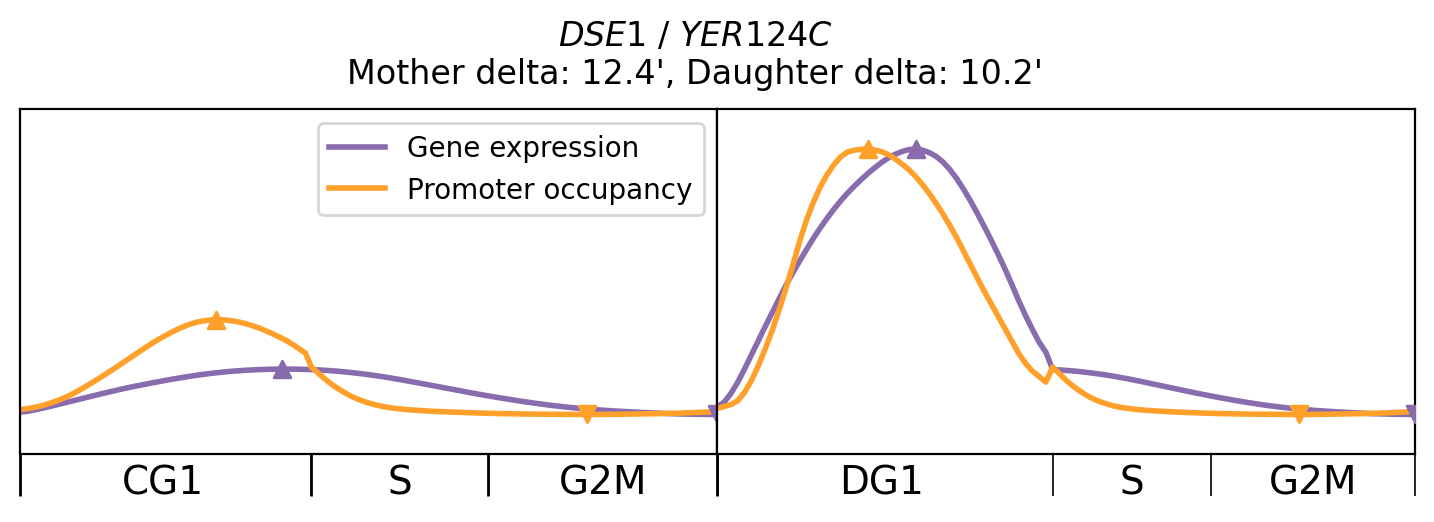

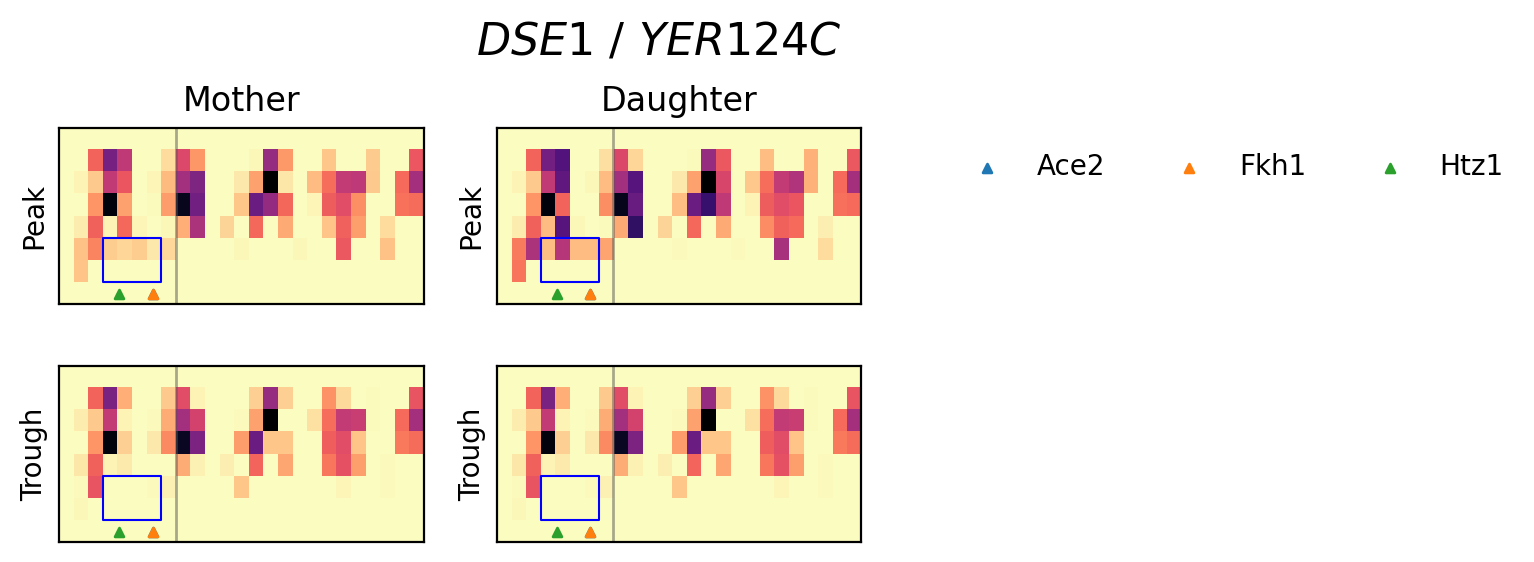

In [431]:
orf_name = 'YER124C'
time_delta_analysis.plot_gene_trace(orf_name)
promoter_analysis.plot_orf_name_imgs(time_delta_analysis, orf_name)